In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings

warnings.filterwarnings('ignore')
print("✅ All imports successful")

✅ All imports successful


In [2]:
df = pd.read_csv('data/multimodal_dementia_dataset.csv')

# Safety checks
assert df.shape == (225, 29), f"Unexpected shape: {df.shape}"
assert df.isnull().sum().sum() == 0, "NaNs found in dataset!"
assert df['Label'].isin([0, 1]).all(), "Invalid labels found!"

print(f"Dataset loaded: {df.shape}")
print(f"Label distribution:\n{df['Label'].value_counts()}")
print(f"Columns: {df.columns.tolist()}")

Dataset loaded: (225, 29)
Label distribution:
Label
0    124
1    101
Name: count, dtype: int64
Columns: ['Subject_ID', 'CDR', 'MMSE', 'ASF', 'EDUC', 'SES', 'nWBV', 'eTIV', 'hippocampal_volume', 'cortical_thickness', 'pause_rate', 'speech_rate', 'pitch_mean', 'jitter', 'shimmer', 'mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8', 'mfcc_9', 'mfcc_10', 'mfcc_11', 'mfcc_12', 'mfcc_13', 'Label']


In [3]:
MFCC_COLS = [f'mfcc_{i}' for i in range(1, 14)]

SPEECH_FEATURES = [
    'pause_rate',
    'speech_rate',
    'pitch_mean',
    'jitter',
    'shimmer'
] + MFCC_COLS

print(f"Total speech features: {len(SPEECH_FEATURES)}")
print(f"Features: {SPEECH_FEATURES}")

print("\n=== SPEECH FEATURE OVERVIEW ===")
print(df[SPEECH_FEATURES[:5]].describe().round(4))

print("\n=== PER-CLASS MEANS ===")
print(
    df.groupby('Label')[['pause_rate', 'speech_rate', 'pitch_mean', 'jitter', 'shimmer']].mean().round(4)
)

Total speech features: 18
Features: ['pause_rate', 'speech_rate', 'pitch_mean', 'jitter', 'shimmer', 'mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5', 'mfcc_6', 'mfcc_7', 'mfcc_8', 'mfcc_9', 'mfcc_10', 'mfcc_11', 'mfcc_12', 'mfcc_13']

=== SPEECH FEATURE OVERVIEW ===
       pause_rate  speech_rate  pitch_mean    jitter   shimmer
count    225.0000     225.0000    225.0000  225.0000  225.0000
mean       0.2684       3.7957    166.7975    0.0181    0.0428
std        0.1081       0.9258     15.9597    0.0075    0.0168
min        0.0758       1.6000    122.1200    0.0040    0.0140
25%        0.1728       2.9590    154.1900    0.0116    0.0289
50%        0.2368       4.0860    166.1900    0.0160    0.0372
75%        0.3697       4.5680    179.7800    0.0246    0.0593
max        0.5299       5.4960    199.1500    0.0356    0.0838

=== PER-CLASS MEANS ===
       pause_rate  speech_rate  pitch_mean  jitter  shimmer
Label                                                      
0          0.1797   

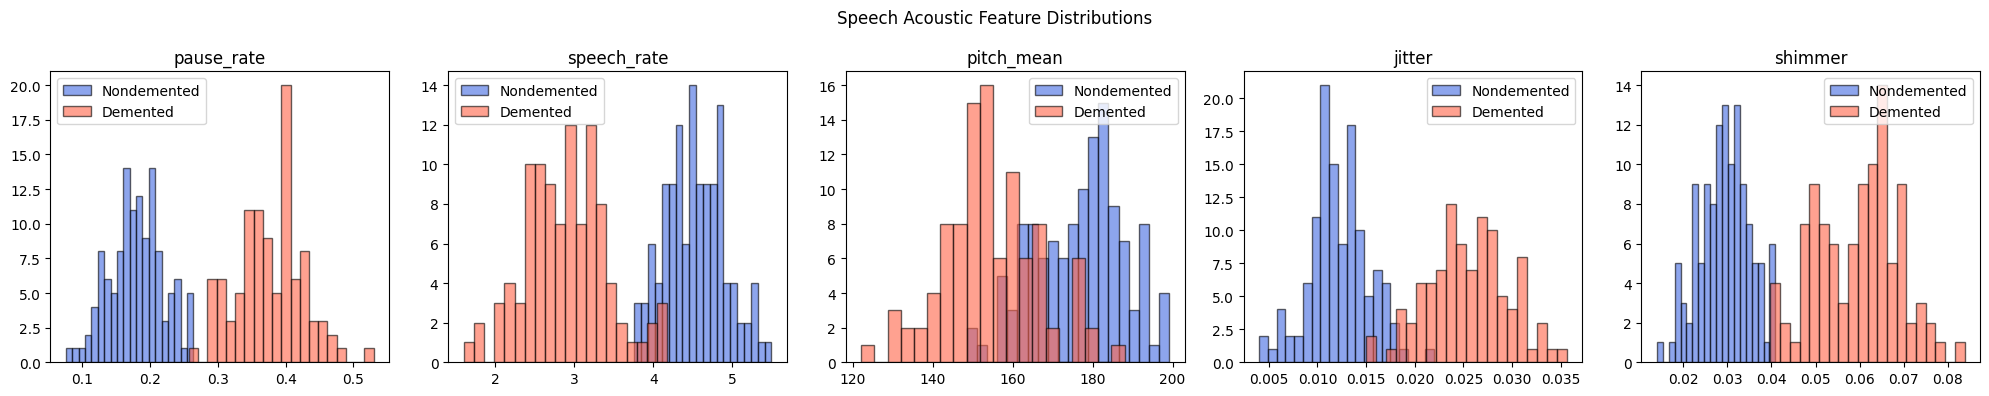

Saved plot → results/plots/speech_feature_distributions.png


In [4]:
acoustic_feats = ['pause_rate', 'speech_rate', 'pitch_mean', 'jitter', 'shimmer']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

colors = {0: 'royalblue', 1: 'tomato'}
labels = {0: 'Nondemented', 1: 'Demented'}

for ax, feat in zip(axes, acoustic_feats):
    for lbl in [0, 1]:
        ax.hist(
            df[df['Label'] == lbl][feat],
            bins=20,
            alpha=0.6,
            color=colors[lbl],
            label=labels[lbl],
            edgecolor='black'
        )
    ax.set_title(feat)
    ax.legend()

plt.suptitle("Speech Acoustic Feature Distributions")
plt.tight_layout()
plt.savefig("results/plots/speech_feature_distributions.png")
plt.show()

print("Saved plot → results/plots/speech_feature_distributions.png")

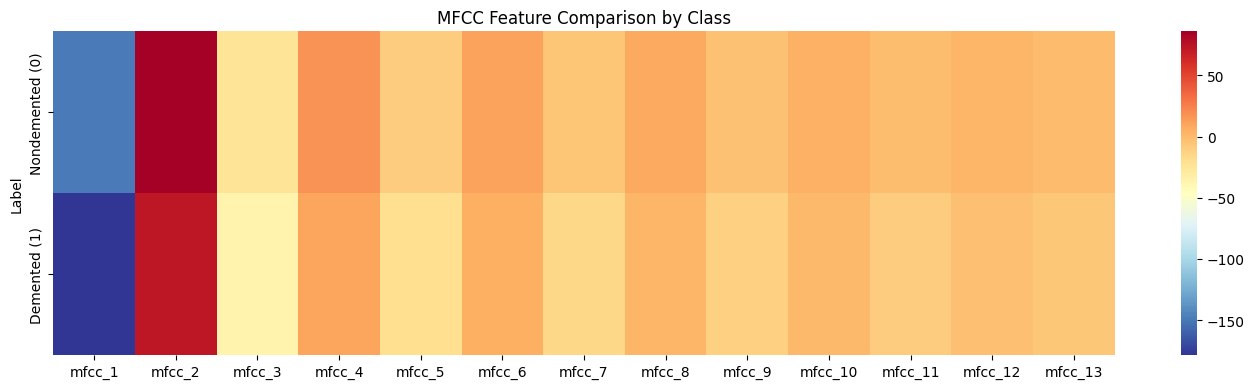

Saved plot → results/plots/mfcc_class_comparison.png


In [5]:
mfcc_means = df.groupby('Label')[MFCC_COLS].mean()

plt.figure(figsize=(14, 4))
sns.heatmap(
    mfcc_means,
    cmap='RdYlBu_r',
    yticklabels=['Nondemented (0)', 'Demented (1)']
)

plt.title("MFCC Feature Comparison by Class")
plt.tight_layout()
plt.savefig("results/plots/mfcc_class_comparison.png")
plt.show()

print("Saved plot → results/plots/mfcc_class_comparison.png")

In [6]:
X_speech = df[SPEECH_FEATURES].values
y = df['Label'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_speech)

print("Shape:", X_scaled.shape)
print("Mean (approx 0):", X_scaled.mean(axis=0)[:5])
print("Std (approx 1):", X_scaled.std(axis=0)[:5])

Shape: (225, 18)
Mean (approx 0): [ 1.18423789e-17  6.02974460e-16 -1.55529910e-15 -5.19090943e-16
  1.06581410e-16]
Std (approx 1): [1. 1. 1. 1. 1.]


Explained variance ratio: [0.39833554 0.06667892]
Total variance retained: 0.46501446267019575
Shape: (225, 2)


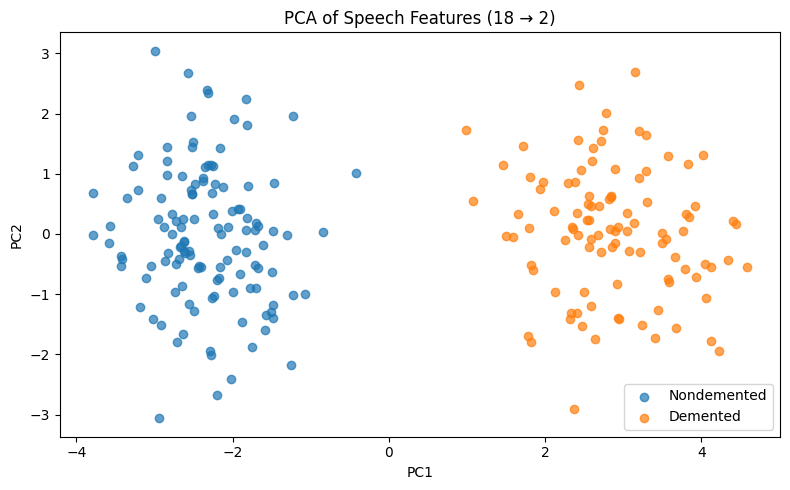

Saved plot → results/plots/speech_pca.png


In [7]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance retained:", sum(pca.explained_variance_ratio_))
print("Shape:", X_pca.shape)

plt.figure(figsize=(8, 5))

plt.scatter(X_pca[y == 0, 0], X_pca[y == 0, 1],
            label="Nondemented", alpha=0.7)

plt.scatter(X_pca[y == 1, 0], X_pca[y == 1, 1],
            label="Demented", alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Speech Features (18 → 2)")
plt.legend()

plt.tight_layout()
plt.savefig("results/plots/speech_pca.png")
plt.show()

print("Saved plot → results/plots/speech_pca.png")

In [8]:
np.save("results/X_speech_pca.npy", X_pca)

print("Saved → results/X_speech_pca.npy")
print("Shape:", X_pca.shape)

# verification
check = np.load("results/X_speech_pca.npy")
assert check.shape == (225, 2), "Shape mismatch!"

print("✅ Verification passed")

Saved → results/X_speech_pca.npy
Shape: (225, 2)
✅ Verification passed
